# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

file_path = '/content/drive/MyDrive/Colab Notebooks/datasets/yulu_rental.csv'
df = pd.read_csv(file_path)

df.head()


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [3]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [4]:
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10886 entries, 2011-01-01 00:00:00 to 2012-12-19 23:00:00
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   season       10886 non-null  int64  
 1   holiday      10886 non-null  int64  
 2   workingday   10886 non-null  int64  
 3   weather      10886 non-null  int64  
 4   temp         10886 non-null  float64
 5   atemp        10886 non-null  float64
 6   humidity     10886 non-null  int64  
 7   windspeed    10886 non-null  float64
 8   casual       10886 non-null  int64  
 9   registered   10886 non-null  int64  
 10  count        10886 non-null  int64  
 11  date         10886 non-null  object 
 12  day          10886 non-null  int32  
 13  week         10886 non-null  UInt32 
 14  weekday_num  10886 non-null  int32  
 15  weekday      10886 non-null  object 
 16  year         10886 non-null  int32  
 17  month        10886 non-null  int32  
 18  hour       

In [5]:
df.index.to_series().diff().value_counts()


,count
datetime,
0 days 01:00:00,10820
0 days 02:00:00,36
12 days 01:00:00,13
11 days 01:00:00,8
0 days 03:00:00,5
0 days 13:00:00,1
9 days 01:00:00,1
10 days 01:00:00,1


Висновки:

Датасет містить 10886 рядків та 19 колонок.
Дані охоплюють період з 01.01.2011 по 19.12.2012.
Рівень деталізації — переважно погодинний: один рядок відповідає одній годині.
Проте в наборі є незначні часові пропуски.



## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


In [6]:
daily = df['count'].resample('D').sum()
daily.head()


,count
datetime,
2011-01-01,985
2011-01-02,801
2011-01-03,1349
2011-01-04,1562
2011-01-05,1600


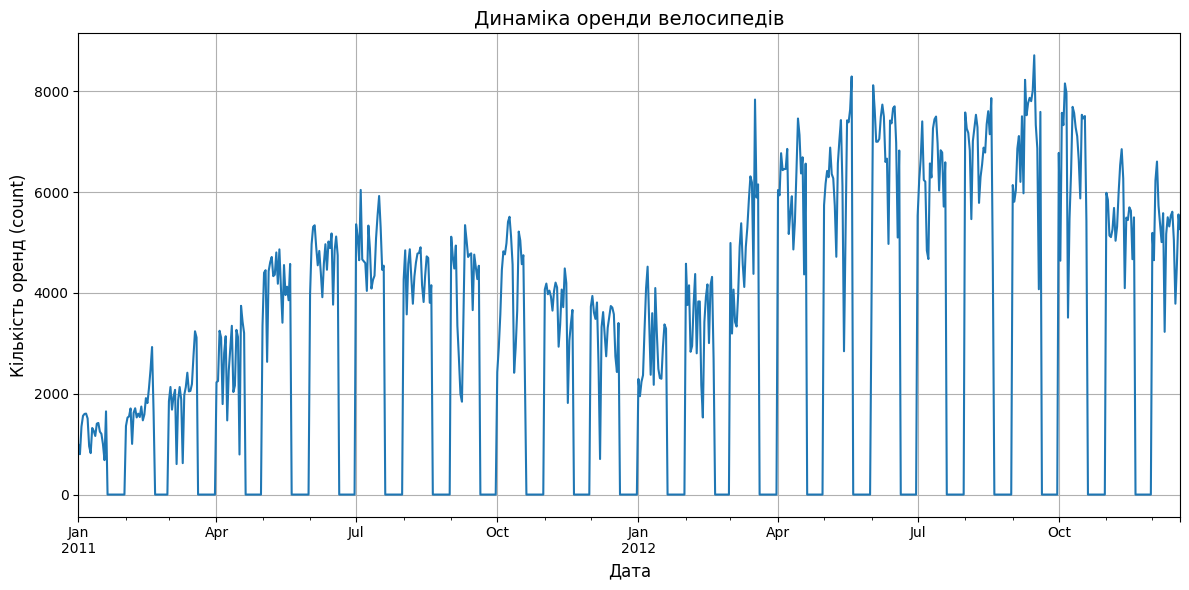

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

daily.plot()

plt.title("Динаміка оренди велосипедів", fontsize=14)
plt.xlabel("Дата", fontsize=12)
plt.ylabel("Кількість оренд (count)", fontsize=12)

plt.grid(True)
plt.tight_layout()
plt.show()



Висновки:

1️. Чому є "заломи"?

Різкі падіння на графіку пов’язані з пропущеними даними або технічними особливостями агрегації. При групуванні по днях деякі періоди можуть мати неповні дані, що призводить до різких провалів.

Для усунення можна застосувати інтерполяцію або згладжування.

2️. Загальні тенденції

Спостерігається загальне зростання кількості оренд у 2012 році порівняно з 2011. Це може свідчити про розвиток та популярність сервісу.

3️. Сезонність

Спостерігаються сезонні коливання: кількість оренд зростає у теплі місяці року та зменшується у холодний період. Подібна сезонність повторюється в обох роках.


4️. Аномалії

Є періоди з дуже низькими та дуже високими значеннями. Низькі можуть бути пов’язані з пропусками або поганою погодою, високі — зі святами або сприятливими умовами.


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

In [9]:
season_avg = df.groupby('season')['count'].mean()
season_avg


,count
season,
1,116.343261
2,215.251372
3,234.417124
4,198.988296


In [10]:
season_labels = {
    1: 'Q1',
    2: 'Q2',
    3: 'Q3',
    4: 'Q4'
}

season_avg.index = season_avg.index.map(season_labels)
season_avg


,count
season,
Q1,116.343261
Q2,215.251372
Q3,234.417124
Q4,198.988296


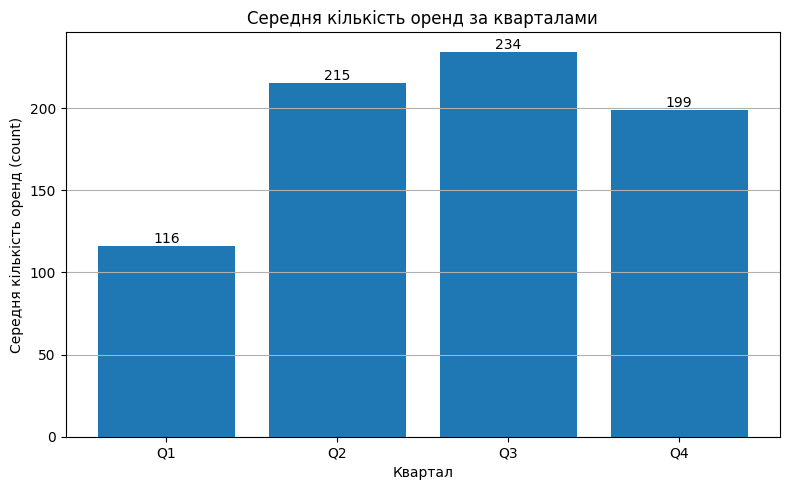

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bars = plt.bar(season_avg.index, season_avg.values)

plt.title("Середня кількість оренд за кварталами")
plt.xlabel("Квартал")
plt.ylabel("Середня кількість оренд (count)")
plt.grid(axis='y')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{height:.0f}',
             ha='center',
             va='bottom')

plt.tight_layout()
plt.show()


Висновки:

1️. В якому кварталі найбільша середня кількість оренд?

Найбільша середня кількість оренд спостерігається у Q3 - 234 оренди.

2️. Як пояснити сезонну закономірність?

Вищі значення у Q2–Q3 можна пояснити більш сприятливими погодними умовами. У теплий період року попит на велосипеди зростає, тоді як у прохолодні місяці активність користувачів зменшується.

3️. У скільки разів відрізняється найпопулярніший і найменш популярний квартали?

Найменше значення — у Q1 (116), найбільше — у Q3 (234).
Q3 приблизно у 2 рази перевищує Q1.

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


In [12]:
monthly_avg = df.groupby('month')['count'].mean()
monthly_avg


,count
month,
1,90.366516
2,110.003330
3,148.169811
4,184.160616
5,219.459430
6,242.031798
7,235.325658
8,234.118421
9,233.805281


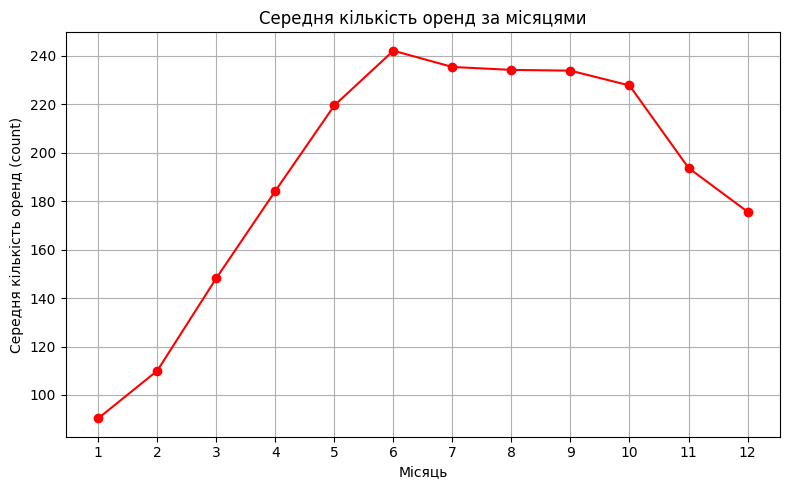

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(monthly_avg.index,
         monthly_avg.values,
         color='red',
         marker='o')

plt.title("Середня кількість оренд за місяцями")
plt.xlabel("Місяць")
plt.ylabel("Середня кількість оренд (count)")

plt.xticks(range(1,13))
plt.grid(True)

plt.tight_layout()
plt.show()


Висновки:

1️. В які місяці спостерігається пік та спад оренди?

Пік оренди спостерігається у червні (6 місяць) — приблизно 242 оренди.
Найнижчий показник - у січні (1 місяць) — близько 90 оренд.

2️. Чи збігається закономірність з попереднім завданням?

Так, результати узгоджуються з квартальним аналізом.
Найвищі значення припадають на середину року (Q2–Q3), а найнижчі — на початок року (Q1).

3️. Як клімат може впливати на оренду?

Кількість оренд зростає у теплі місяці року, коли погодні умови сприятливі для використання велосипедів. У холодний або дощовий період активність користувачів знижується.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

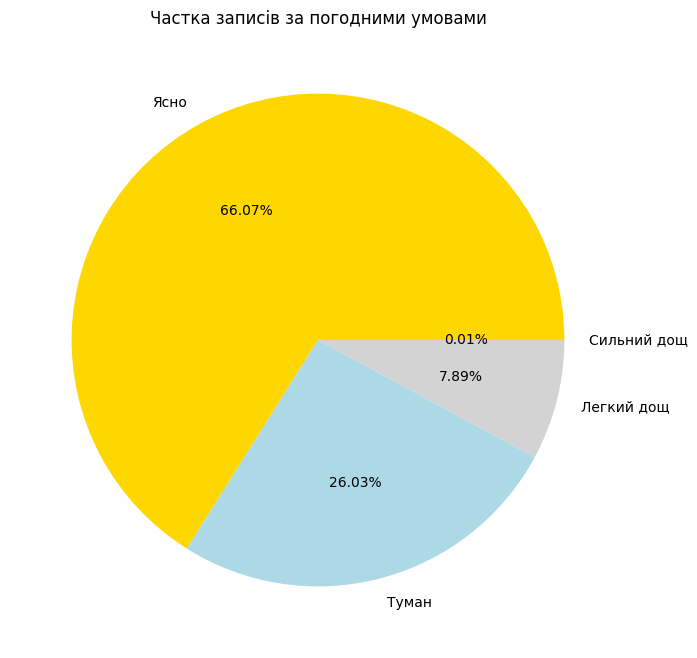

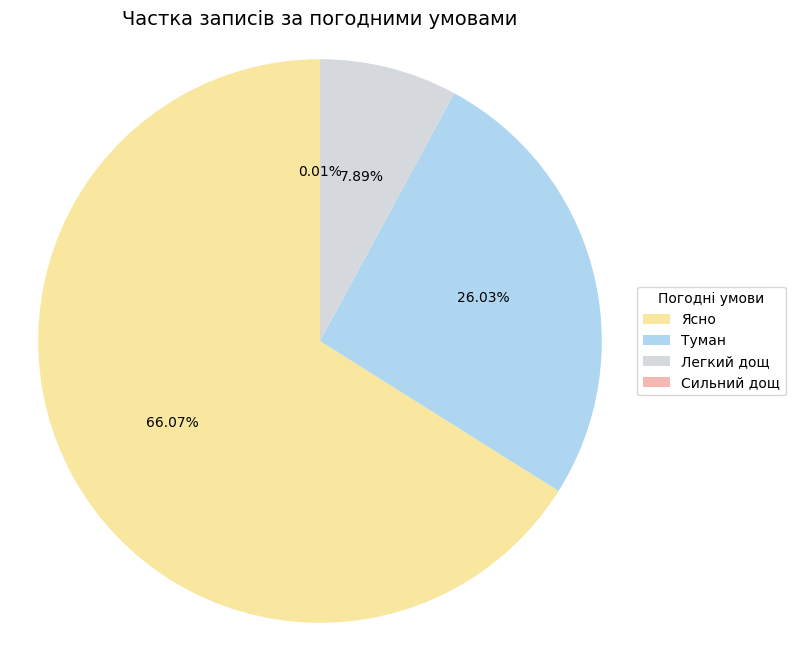

In [20]:
import matplotlib.pyplot as plt

weather_counts = df['weather'].value_counts().sort_index()

labels = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']
colors = ['#F9E79F', '#AED6F1', '#D5D8DC', '#F5B7B1']

plt.figure(figsize=(8,8))

wedges, texts, autotexts = plt.pie(
    weather_counts,
    autopct='%1.2f%%',
    colors=colors,
    startangle=90
)

plt.title("Частка записів за погодними умовами", fontsize=14)
plt.axis('equal')

plt.legend(wedges, labels, title="Погодні умови", loc="center left", bbox_to_anchor=(1, 0.5))

plt.show()




Висновки:

1. Яка погода переважає в датасеті?
Переважає ясна погода - близько 66% усіх записів.

2. Чи є дні із сильним дощем? Яка їх частка?
Так, є, але їх дуже мало - приблизно 0.01% від усіх днів.

3. Як погодні умови впливають на попит на оренду велосипедів?
У ясну погоду попит вищий, оскільки умови комфортні для поїздок. Під час дощу або туману кількість оренд зменшується через менш сприятливі умови.

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

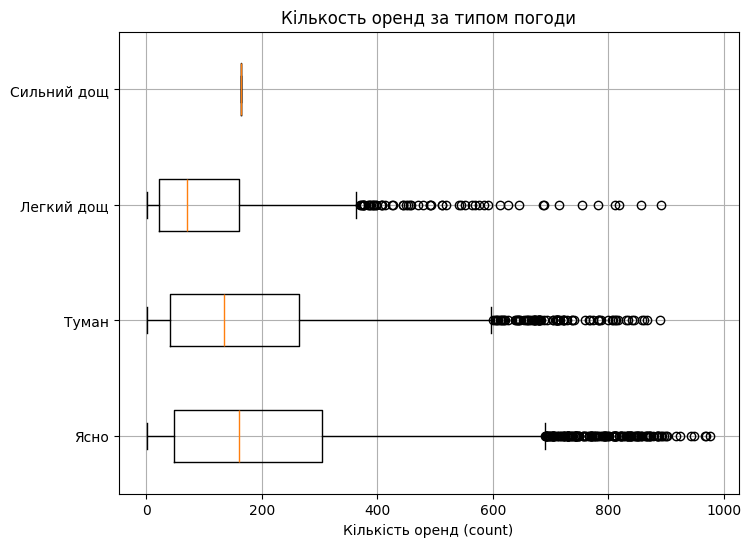

In [21]:
import matplotlib.pyplot as plt

weather_labels = {
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
}

data = [
    df[df['weather'] == 1]['count'],
    df[df['weather'] == 2]['count'],
    df[df['weather'] == 3]['count'],
    df[df['weather'] == 4]['count']
]

plt.figure(figsize=(8,6))

plt.boxplot(data, vert=False)

plt.yticks([1,2,3,4], weather_labels.values())
plt.xlabel("Кількість оренд (count)")
plt.title("Кількость оренд за типом погоди")

plt.grid(True)
plt.show()


Висновки:

1. При якій погоді найбільший розкид у кількості оренди?
Найбільший розкид спостерігається при ясній погоді — значення варіюються в широкому діапазоні.

2. Чи є викиди (outliers) в даних? При якій погоді?
Так, викиди є, особливо при ясній погоді та тумані. При сильному дощі їх майже немає.

3. При якій погоді медіанне значення оренди найвище?
Найвища медіана також при ясній погоді.

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

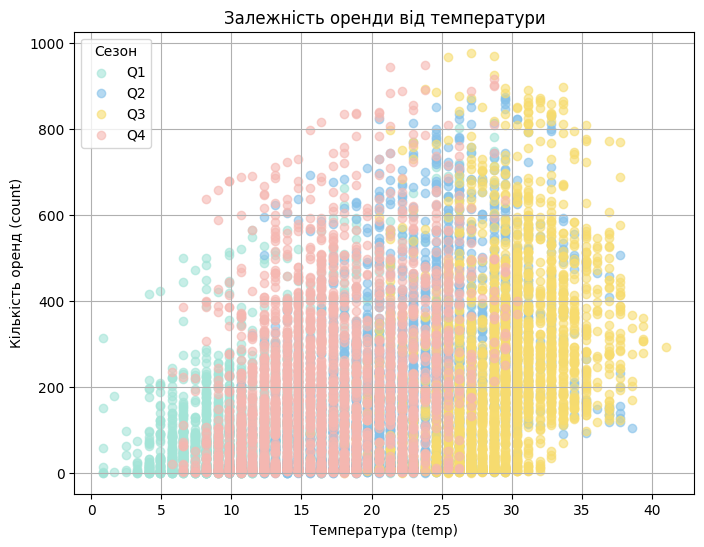

In [22]:
import matplotlib.pyplot as plt

season_colors = {
    1: '#A3E4D7',  # Q1
    2: '#85C1E9',  # Q2
    3: '#F7DC6F',  # Q3
    4: '#F5B7B1'   # Q4
}

plt.figure(figsize=(8,6))

for season in df['season'].unique():
    subset = df[df['season'] == season]
    plt.scatter(
        subset['temp'],
        subset['count'],
        alpha=0.6,
        color=season_colors[season],
        label=f'Q{season}'
    )

plt.xlabel("Температура (temp)")
plt.ylabel("Кількість оренд (count)")
plt.title("Залежність оренди від температури")
plt.legend(title="Сезон")
plt.grid(True)

plt.show()


Висновок:

Чи є зв'язок між температурою та кількістю оренди? Який?
Так, спостерігається позитивний зв’язок: зі зростанням температури кількість оренд збільшується. При низьких температурах оренд мало, а в теплі періоди їх значно більше. Це свідчить про помірну позитивну кореляцію між температурою та попитом.


## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

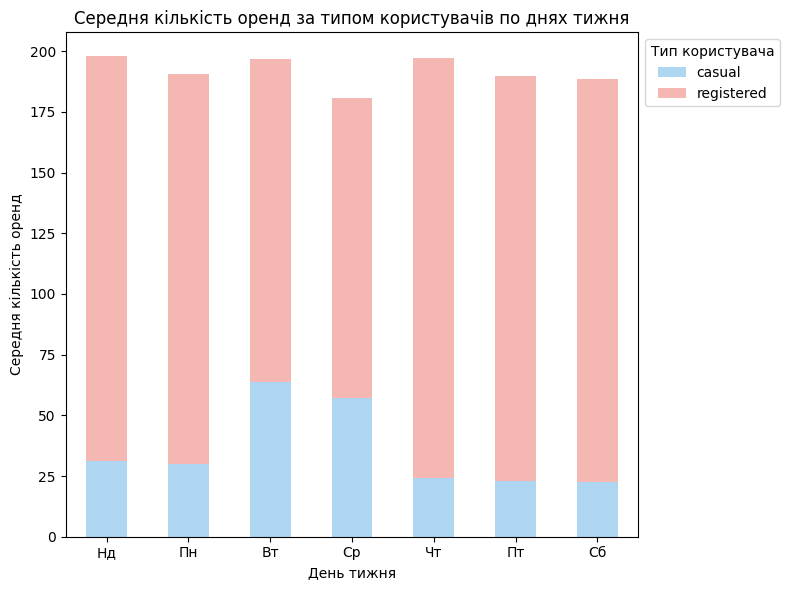

In [25]:
ax = weekday_avg.plot(
    kind='bar',
    stacked=True,
    figsize=(8,6),
    color=['#AED6F1', '#F5B7B1'],
    title="Середня кількість оренд за типом користувачів по днях тижня"
)

plt.xlabel("День тижня")
plt.ylabel("Середня кількість оренд")

plt.xticks(rotation=0)
plt.legend(title="Тип користувача", loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()




Висновки:

1. В які дні тижня більше оренд від зареєстрованих користувачів?
Більше оренд від зареєстрованих користувачів спостерігається у будні дні (особливо вівторок–четвер).

2. Як можна пояснити таку різницю в поведінці користувачів протягом тижня?
Зареєстровані користувачі, ймовірно, використовують велосипеди для регулярних поїздок на роботу чи навчання в будні. У вихідні активність більшою мірою пов’язана з відпочинком, тому частка випадкових користувачів зростає.